# FLUKA vs DPMJET-III 19.3: residual nuclei in pPb

Generate pPb events at 5 TeV center-of-mass (per nucleon-nucleon pair) with FLUKA and DpmjetIII193 and compare the mass-number distribution $A$ of residual/fragment nuclei in the final state.

Residual nuclei are identified by PDG nuclear codes (`|pid| > 1e9`, format `10LZZZAAAI`). Free nucleons (`2212`, `2112`) are excluded, so the histogram reflects bound fragments only ($A \geq 2$).

Requires: matplotlib, tqdm, boost-histogram, joblib, particle.

**Note on kinematics.** chromo's `CenterOfMass` takes the nucleon-nucleon CMS energy for ion systems. 5 TeV here means $\sqrt{s_{NN}} = 5$ TeV, i.e. LHC pPb territory. This is above FLUKA 2025.1's event-generation ceiling of ~20 TeV/nucleon *in the lab frame* — for $\sqrt{s_{NN}} = 5$ TeV the equivalent lab energy is well beyond that. Lower the energy if FLUKA aborts.

In [1]:
import os
os.environ["FLUPRO"] = "/home/anatoli/devel/FLUKA"

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import boost_histogram as bh
from tqdm import tqdm
import joblib
import numpy as np

from chromo.constants import GeV, TeV
from chromo.kinematics import CenterOfMass
from chromo.models import DpmjetIII193
from chromo.models.fluka import Fluka

In [ ]:
# pPb at sqrt(s_NN) = 5 TeV. Target Pb208 is in chromo's FLUKA default
# material list, so no targets= override is needed.
ekin = CenterOfMass(5 * TeV, "proton", "Pb208")

n_events = 2000

# A-axis: one bin per integer mass number from A=1 to A=210
# (Pb has A=208; leave headroom for any Bi-like coded residuals).
a_axis = bh.axis.Regular(210, 0.5, 210.5)

In [9]:
models = [Fluka, DpmjetIII193]

@joblib.delayed
def run(Model):
    # Models are single-instantiation per process; joblib with loky backend
    # gives each model its own subprocess.
    m = Model(ekin, seed=1)

    hA = bh.Histogram(a_axis)

    for event in tqdm(m(n_events), total=n_events, desc=m.label):
        fs = event.final_state()
        pid = np.abs(fs.pid.astype(np.int64))
        # Nuclear PDG code: 10LZZZAAAI with |pid| > 1e9.
        # A = digits at positions 4..6 from the right: (pid // 10) % 1000.
        nuc = pid >= 1_000_000_000
        if not np.any(nuc):
            continue
        A = (pid[nuc] // 10) % 1000
        hA.fill(A)

    return m.label, hA

with joblib.Parallel(n_jobs=len(models), batch_size=1) as pool:
    results = pool(run(M) for M in models)

results = dict(results)
list(results)

 +-----------------------------------------------------------------------+
 |                                                                       |
 |                       DPMJET-III version 19.3.8                       |
 |                                                                       |
 |                      (Last change:  10 Jun 2025)                      |
 |                                                                       |
 |            Authors:                                                   |
 |                     Stefan Roesler     (CERN)                         |
 |                     Anatoli Fedynitch (ASIoP)                         |
 |                     Ralph Engel        (KIT)                          |
 |                     Johannes Ranft     (Siegen Univ.)                 |
 |                                                                       |
 |        https://github.com/DPMJET/DPMJET                           |
 |                           

FLUKA-2025.1:   7%|▋         | 142/2000 [00:00<00:11, 155.31it/s]

1                                                                              
 ******************************************************************************
 ******************************************************************************
 **                                                                          **
 **                                                                          **
 **              *......*                  Welcome to the Lund Monte Carlo!  **
 **         *:::!!:::::::::::*                                               **
 **      *::::::!!::::::::::::::*          PPP  Y   Y TTTTT H   H III   A    **
 **    *::::::::!!::::::::::::::::*        P  P  Y Y    T   H   H  I   A A   **
 **   *:::::::::!!:::::::::::::::::*       PPP    Y     T   HHHHH  I  AAAAA  **
 **   *:::::::::!!:::::::::::::::::*       P      Y     T   H   H  I  A   A  **
 **    *::::::::!!::::::::::::::::*!       P      Y     T   H   H III A   A  **
 **      *::::::!!::::::::::::::* !!    

FLUKA-2025.1:  19%|█▉        | 386/2000 [00:02<00:11, 136.15it/s]/home/anatoli/devel/chromo/src/chromo/common.py:875: RuntimeWarning: DpmjetIII193: {np.int32(111)} haven't been decayed. Consider to use generator._activate_decay_handler(on=True)
  warnings.warn(
DPMJET-III-19.3:   4%|▍         | 86/2000 [00:19<03:28,  9.17it/s]/home/anatoli/devel/chromo/src/chromo/common.py:875: RuntimeWarning: DpmjetIII193: {np.int32(3212), np.int32(111)} haven't been decayed. Consider to use generator._activate_decay_handler(on=True)
  warnings.warn(
DPMJET-III-19.3:  27%|██▋       | 540/2000 [00:19<00:05, 259.83it/s]/home/anatoli/devel/chromo/src/chromo/common.py:875: RuntimeWarning: DpmjetIII193: {np.int32(3212)} haven't been decayed. Consider to use generator._activate_decay_handler(on=True)
  warnings.warn(
DPMJET-III-19.3:  61%|██████    | 1212/2000 [00:20<00:01, 684.37it/s]


     Advisory warning type 3 given after     1791 PYEXEC calls:
     (PYPREP:) too small mass in jet system


DPMJET-III-19.3: 100%|██████████| 2000/2000 [00:21<00:00, 91.00it/s] 


['FLUKA-2025.1', 'DPMJET-III-19.3']

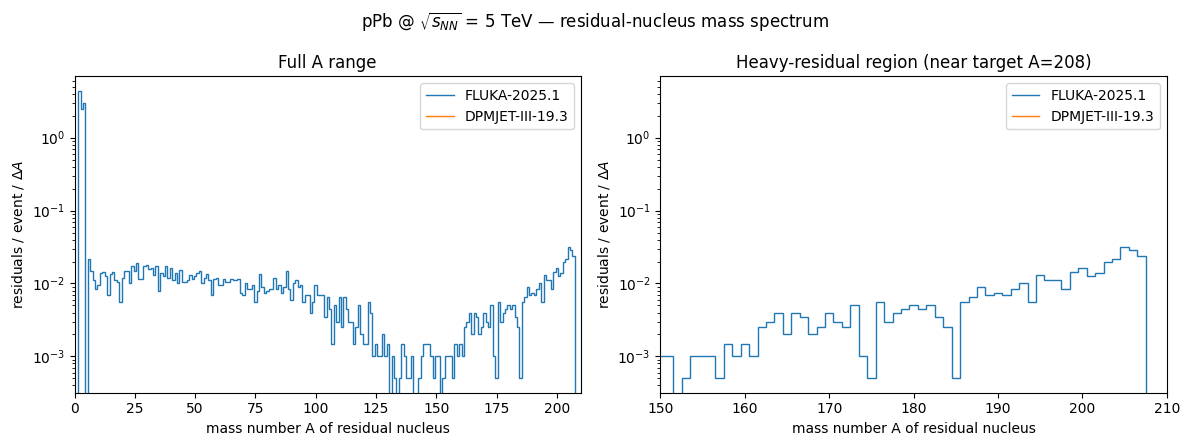

In [11]:
fig, (ax_full, ax_heavy) = plt.subplots(1, 2, figsize=(12, 4.5))

for label, hA in results.items():
    a = hA.axes[0]
    vals = hA.values() / n_events  # residuals per event per unit A
    ax_full.stairs(vals, a.edges, label=label)
    ax_heavy.stairs(vals, a.edges, label=label)

for ax in (ax_full, ax_heavy):
    ax.set_xlabel("mass number A of residual nucleus")
    ax.set_ylabel("residuals / event / $\\Delta A$")
    ax.set_yscale("log")
    ax.legend()

ax_full.set_title("Full A range")
ax_full.set_xlim(0, 210)

ax_heavy.set_title("Heavy-residual region (near target A=208)")
ax_heavy.set_xlim(150, 210)

fig.suptitle("pPb @ $\\sqrt{s_{NN}}$ = 5 TeV — residual-nucleus mass spectrum")
fig.tight_layout();

In [12]:
# Quick summary: mean and max A of residuals per event, and the fraction
# of events that produced at least one bound fragment.
for label, hA in results.items():
    vals = hA.values()
    centers = hA.axes[0].centers
    total = vals.sum()
    if total == 0:
        print(f"{label}: no residual nuclei recorded")
        continue
    mean_A = (centers * vals).sum() / total
    # heaviest populated bin
    max_A = centers[np.nonzero(vals)[0][-1]]
    per_event = total / n_events
    print(f"{label:>15}: <A>={mean_A:6.2f}  A_max={max_A:6.1f}  residuals/event={per_event:.3f}")

   FLUKA-2025.1: <A>= 14.63  A_max= 207.0  residuals/event=11.409
DPMJET-III-19.3: no residual nuclei recorded
